# A Birkin vs the S&P and gold — a quantitative teardown 🔬
### Resale index vs SPY & GLD (CAGR / vol / MDD + annual-excess *t*) · Newey-West maison alpha · the ~30% consignment haircut on NAV · a synthetic compounder positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_stocks_%26_gold%3F: Busted](https://img.shields.io/badge/Beats_stocks_%26_gold%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "a Birkin beats the S&P and gold": (H₁) the secondary-market resale index out-returns SPY *and* GLD risk-adjusted; (H₂) a buyable maison proxy carries alpha vs the market; (H₃) it survives the transaction + carry cost of owning a physical bag. We find **H₁ rejected** (it *under*-performs both), **H₂ not established** (the best leg, RMS.PA, is *t* = 1.93 < 2), **H₃ rejected** (negative net of the consignment spread).

> ⚠️ **Not investment advice — data provenance.** The Birkin resale index is **hardcoded, cited, approximate** (Baghunter 2016 headline + Knight Frank Luxury Investment Index + press reporting — a *labelled proxy*, never the live feed). Equity/gold proxies `RMS.PA`, `MC.PA`, `KER.PA`, `SPY`, `GLD` are month-end Adj Close via yfinance (as-of 2025-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
GOLD = "#c9a227"

from birkin_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_resale_index()                       # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity/gold-proxy cache present:", HAVE_PROXIES,
      "| Birkin-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2015 → 2025', 'idx_levels': {2015: 100, 2016: 106, 2017: 113, 2018: 121, 2019: 128, 2020: 134, 2021: 150, 2022: 162, 2023: 166, 2024: 158, 2025: 163}, 'idx_yoy': {2016: 6.0, 2017: 6.6, 2018: 7.1, 2019: 5.8, 2020: 4.7, 2021: 11.9, 2022: 8.0, 2023: 2.5, 2024: -4.8, 2025: 3.2}, 'myth_cagr': 14.2, 'myth_window': '1980–2015', 'myth_sp500': 8.7, 'idx_cagr': 5.01, 'idx_vol': 4.4, 'idx_sharpe': 1.16, 'idx_mdd': -4.8, 'spy_cagr_ye': 14.71, 'spy_vol_ye': 15.7, 'spy_mdd_ye': -18.2, 'gld_cagr_ye': 14.6, 'gld_vol_ye': 19.9, 'gld_mdd_ye': -4.9, 'excess_spy_mean': -10.71, 'excess_spy_t': -1.952, 'excess_spy_p': 0.083, 'excess_n': 10, 'excess_gld_mean': -10.88, 'excess_gld_t': -1.524, 'excess_gld_p': 0.162, 'rms_cagr': 20.85, 'rms_vol': 24.5, 'rms_sharpe': 0.9, 'rms_mdd': -35.0, 'rms_alpha': 11.88, 'rms_beta': 0.76, 'rms_t': 1.93, 'rms_p': 0.055, 'rms_n': 131, 'mc_cagr': 16.85, 'mc_vol': 24.1, 'mc_sharpe': 0.77, 'mc_mdd': -46.8, 'mc_alpha': 6.16, 'mc_beta': 0.89, 'mc_t': 0.93, 'mc_p': 0.354, 'ker_cagr': 7.97, 'ker_vol': 31.3, 'ker_sharpe': 0.4, 'ker_mdd': -74.3, 'ker_alpha': -1.64, 'ker_beta': 1.0, 'ker_t': -0.18, 'ker_p': 0.855, 'spy_cagr': 13.84, 'spy_vol': 15.0, 'spy_sharpe': 0.95, 'spy_mdd': -23.9, 'gld_cagr': 11.28, 'gld_vol': 14.3, 'gld_sharpe': 0.82, 'gld_mdd': -18.1, 'carry_gross': 5.01, 'carry_spread': -11.21, 'carry_insure': -0.5, 'carry_net': -7.23, 'syn_peak': 316, 'syn_end': 270, 'syn_cagr': 10.54, 'syn_sharpe': 1.0, 'syn_mdd': -21.8}


equity/gold-proxy cache present: True | Birkin-index years: 2015 -> 2025


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Resale index CAGR **5.0%** vs SPY **14.7%** and GLD **14.6%** (2015–2025); annual excess **-10.7%/yr** vs SPY (*t* = **-1.95**), **-10.9%/yr** vs GLD (*t* = **-1.52**), n=10. Best maison alpha (RMS.PA) NW *t* = **+1.93** — under the bar. |
| **Tradability** | `MIRAGE` | Gross index CAGR **+5.0%** → **NET -7.2%/yr** after a 30% consignment spread + carry. Buyable proxies are single-stock luxury beta (KER.PA maxDD **-74%**). Illiquid, wide-spread. |
| **Beats stocks & gold?** | `BUSTED` | The bag loses the CAGR race to **both** SPY (14.7) and GLD (14.6), and net-of-cost goes negative. Every column the headline names. |

> 💡 In plain words: the handbag is a lovely low-vol *store of value* but a poor *return* — it trailed both stocks and gold, the only tradable expression is single-name luxury beta, and the ~30% consignment friction turns even the gross return negative. The famous 14%/yr is a cherry-picked, survivorship-laden 1980–2015 marketing figure.

## 1 · The claim, steelmanned

Let the secondary-market Birkin level be $I_t$ and the benchmarks $B_t$ (SPY) and $G_t$ (GLD). The claim is a joint hypothesis:

- **H₁ (it out-returns).** Annual excess $\;x_t = r^I_t - r^B_t\;$ (and vs gold) has $\mathbb{E}[x_t] > 0$ with $t > 2$ — the bag beats stocks *and* gold, risk-adjusted.
- **H₂ (it's buyable with alpha).** For a tradable maison proxy $P$, the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ is positive with a Newey-West *t* > 2.
- **H₃ (it survives carry).** The net CAGR after the consignment round-trip spread $s$ over hold $h$ and annual carry $c$ stays positive: $(1+g)(1+((1-s)^{1/h}-1))(1-c)-1 > 0$.

The Baghunter 2016 figure ($\sim$14.2%/yr, 1980–2015, "never a down year") is the steelman. The test is whether it holds over a **modern, measurable, risk-adjusted, net-of-cost** window — i.e. whether it's an asset class or a marketing statistic.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, the Birkin would be a genuine diversifier: it would beat *both* the growth asset (equities) *and* the classic inflation hedge (gold), wearable, near-zero drawdown — the exact pitch. But each leg is separately falsifiable. H₁ is a **return race** on a common clock against two named benchmarks. H₂ asks whether the *only investable expression* (listed maisons) delivers anything beyond market beta — you cannot custody "the index." H₃ is the **microstructure tax**: a physical bag has a ~30% consignment/dealer round-trip and a multi-year hold with insurance and authentication carry, frictions an ETF never pays. The asset-class claim needs all three; failing any one downgrades it to folklore.

## 3 · How we'd know — the protocol

- **Resale index (proxy).** A hardcoded, cited, **approximate** annual level (base 100 @ 2015), reconstructed from public reporting (Hermès primary hikes; the 2020–22 resale melt-up; the 2023–24 luxury-handbag *cooling* Knight Frank flagged). *Labelled a proxy* — its path is defensible, its precise year-end values are not a live feed.
- **Equity/gold proxies.** `RMS.PA`, `MC.PA`, `KER.PA`, `SPY`, `GLD` month-end Adj Close (yfinance, cached). Survivorship is **not** a concern here (named tickers, not a screen); the resale index's *level* survivorship — bags that stopped trading drop out — is named, and it biases the claim **upward**.
- **Signal test.** (i) Paired annual-excess $t$ of $r^I - r^B$ vs SPY *and* GLD (small-$n$, weak by construction). (ii) **Newey-West (6-lag) HAC** $t$ of each maison alpha vs SPY — the bar for `REAL` is *t* ≥ 2 in the bag's favour.
- **Cost (beat 6).** Charge the consignment round-trip spread (30% over a 3y hold) + 0.5%/yr carry **once on NAV**; net CAGR.
- **Positive control.** A deterministic *steady-compounder* path with a *planted* drift; the engine must recover the up-sign and a finite Sharpe — proof a null on the real tape is a real null, not a broken harness.
- **What would make us say "asset class":** H₁ *t* > 2 vs **both** benchmarks **or** a maison alpha *t* > 2, **and** a positive net-of-cost CAGR. We find none of these.

## 4 · The teardown

### 4a · The race — resale index vs SPY *and* gold, risk-adjusted

Year-end levels rebased to \$100, all three on one clock. CAGR, vol and max-drawdown in the print; the paired annual-excess *t* against each benchmark.

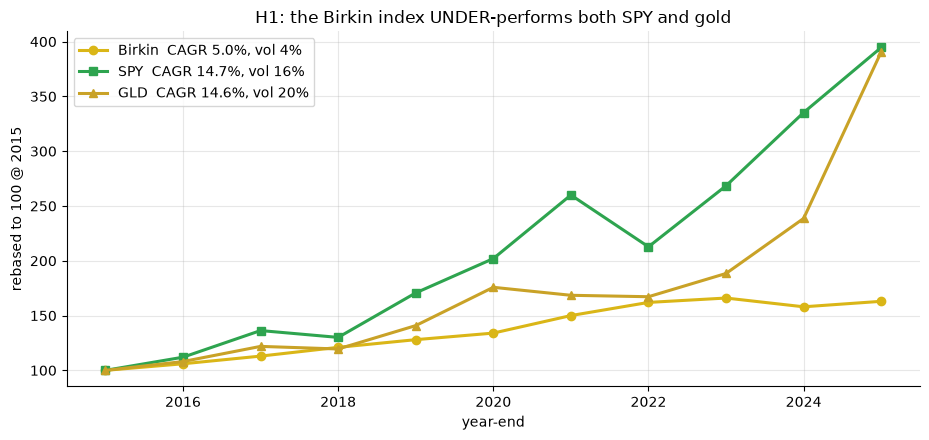

Birkin: CAGR 5.01%  vol 4.4%  maxDD -4.8%
SPY   : CAGR 14.71%  vol 15.7%  maxDD -18.2%
GLD   : CAGR 14.60%  vol 19.9%  maxDD -4.9%
excess idx-SPY: -10.71%/yr  t=-1.952  (n=10)
excess idx-GLD: -10.88%/yr  t=-1.524  (n=10)


In [2]:
yrs = list(R['idx_levels'].keys())
lv = np.array([float(IDX.loc[f'{y}-12-31']) for y in yrs])
si = st.summarize(IDX, periods_per_year=1.0)
if HAVE_PROXIES:
    def ye(t):
        s = PROX[t].resample('YE').last(); return s[(s.index.year>=2015)&(s.index.year<=2025)]
    spy_ye, gld_ye = ye('SPY'), ye('GLD')
    ss, sg = st.summarize(spy_ye, 1.0), st.summarize(gld_ye, 1.0)
    aes, aeg = st.annual_excess_t(IDX, PROX['SPY']), st.annual_excess_t(IDX, PROX['GLD'])
    spy = (spy_ye/spy_ye.iloc[0]*100).values; gld = (gld_ye/gld_ye.iloc[0]*100).values
    sx = [d.year for d in spy_ye.index]
else:
    spy = np.array([100*(1+R['spy_cagr_ye']/100)**(y-2015) for y in yrs])
    gld = np.array([100*(1+R['gld_cagr_ye']/100)**(y-2015) for y in yrs]); sx=yrs
    si={'cagr':R['idx_cagr']/100,'vol':R['idx_vol']/100,'mdd':R['idx_mdd']/100}
    ss={'cagr':R['spy_cagr_ye']/100,'vol':R['spy_vol_ye']/100,'mdd':R['spy_mdd_ye']/100}
    sg={'cagr':R['gld_cagr_ye']/100,'vol':R['gld_vol_ye']/100,'mdd':R['gld_mdd_ye']/100}
    aes={'mean_excess':R['excess_spy_mean']/100,'t':R['excess_spy_t'],'n':R['excess_n']}
    aeg={'mean_excess':R['excess_gld_mean']/100,'t':R['excess_gld_t'],'n':R['excess_n']}
fig, ax = plt.subplots(figsize=(9.4, 4.5))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"Birkin  CAGR {si['cagr']*100:.1f}%, vol {si['vol']*100:.0f}%")
ax.plot(sx, spy, 's-', c=GREEN, lw=2.2, label=f"SPY  CAGR {ss['cagr']*100:.1f}%, vol {ss['vol']*100:.0f}%")
ax.plot(sx, gld, '^-', c=GOLD, lw=2.2, label=f"GLD  CAGR {sg['cagr']*100:.1f}%, vol {sg['vol']*100:.0f}%")
ax.set_xlabel('year-end'); ax.set_ylabel('rebased to 100 @ 2015')
ax.set_title('H1: the Birkin index UNDER-performs both SPY and gold'); ax.legend()
plt.tight_layout(); plt.show()
print(f"Birkin: CAGR {si['cagr']*100:.2f}%  vol {si['vol']*100:.1f}%  maxDD {si['mdd']*100:.1f}%")
print(f"SPY   : CAGR {ss['cagr']*100:.2f}%  vol {ss['vol']*100:.1f}%  maxDD {ss['mdd']*100:.1f}%")
print(f"GLD   : CAGR {sg['cagr']*100:.2f}%  vol {sg['vol']*100:.1f}%  maxDD {sg['mdd']*100:.1f}%")
print(f"excess idx-SPY: {aes['mean_excess']*100:+.2f}%/yr  t={aes['t']:+.3f}  (n={aes['n']})")
print(f"excess idx-GLD: {aeg['mean_excess']*100:+.2f}%/yr  t={aeg['t']:+.3f}  (n={aeg['n']})")

> 💡 In plain words: the Birkin compounds at **5.0%** against SPY's **14.7%** and gold's **14.6%** — it loses *both* races. The mean annual excess is **-10.7%/yr** vs SPY (*t* = **-1.95**) and **-10.9%/yr** vs gold (*t* = **-1.52**), n=10. Its saving grace is *low vol* — a genuine store-of-value trait — but on **return**, H₁ is rejected against both benchmarks. The honest stamp is `NONE`, leaning negative.

### 4b · The buyable maisons — is there alpha, or just luxury beta?

Newey-West (6-lag) regression of each maison's **monthly** return on SPY. `REAL` needs $t_\alpha \ge 2$ — the bar the *bag* itself never approaches, so this is the claim's best shot.

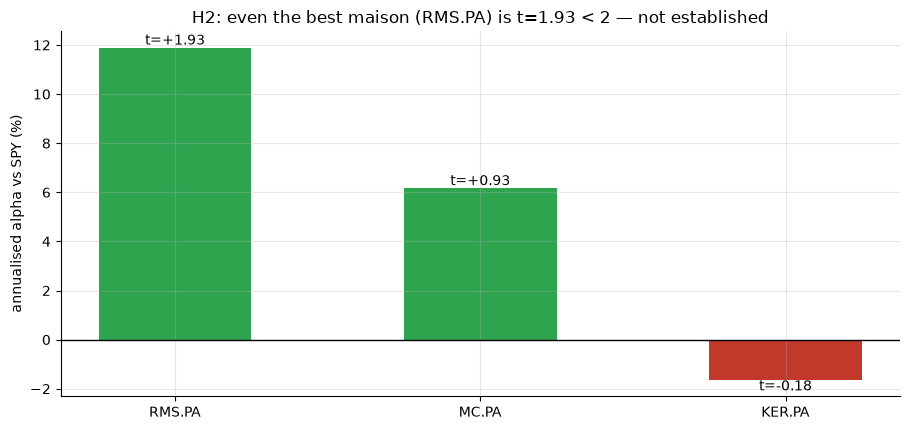

RMS.PA  CAGR  20.85%  Sharpe 0.90  maxDD  -35.0%  alpha +11.88%/yr  beta 0.76  NW t +1.93
MC.PA   CAGR  16.85%  Sharpe 0.77  maxDD  -46.8%  alpha +6.16%/yr  beta 0.89  NW t +0.93
KER.PA  CAGR   7.97%  Sharpe 0.40  maxDD  -74.3%  alpha -1.64%/yr  beta 1.00  NW t -0.18


In [3]:
if HAVE_PROXIES:
    spy_r = PROX['SPY'].pct_change().dropna()
    rows = {}
    for t in ['RMS.PA','MC.PA','KER.PA']:
        s = st.summarize(PROX[t]); nw = st.newey_west_alpha_t(PROX[t].pct_change().dropna(), spy_r, 6)
        rows[t] = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
                       alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
else:
    rows = {'RMS.PA':dict(cagr=R['rms_cagr'],sharpe=R['rms_sharpe'],mdd=R['rms_mdd'],alpha=R['rms_alpha'],beta=R['rms_beta'],t=R['rms_t']),
            'MC.PA':dict(cagr=R['mc_cagr'],sharpe=R['mc_sharpe'],mdd=R['mc_mdd'],alpha=R['mc_alpha'],beta=R['mc_beta'],t=R['mc_t']),
            'KER.PA':dict(cagr=R['ker_cagr'],sharpe=R['ker_sharpe'],mdd=R['ker_mdd'],alpha=R['ker_alpha'],beta=R['ker_beta'],t=R['ker_t'])}
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols=[GREEN if a>0 else RED for a in alphas]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs SPY (%)')
for i,t in enumerate(labels): ax.annotate(f"t={ts[i]:+.2f}",(i,alphas[i]),ha='center',va='bottom' if alphas[i]>=0 else 'top')
ax.set_title('H2: even the best maison (RMS.PA) is t=1.93 < 2 — not established')
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t:7s} CAGR {r['cagr']:6.2f}%  Sharpe {r['sharpe']:.2f}  maxDD {r['mdd']:6.1f}%  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: this is the claim's strongest card, and it's still short. Hermès (**RMS.PA**) *did* out-return SPY with a **+12%/yr** alpha — but at Newey-West **t = +1.93**, just **under** the *t* ≥ 2 bar, so `REAL` is not earned (it reads `WEAK` at most). LVMH is insignificant (*t*=+0.93) and Kering is *negative* (*t*=-0.18, maxDD **-74%**). And crucially: this is the *equity of the company*, driven by watches, leather, beauty, fashion and buybacks — **not the resale price of a Birkin**. H₂ is not established.

### 4c · The microstructure tax — net of the consignment spread + carry

A physical flip pays a ~30% round-trip spread over a ~3-year hold plus ~0.5%/yr carry. Charge it once on the index's gross CAGR (a *generous* read — it ignores that the quoted resale level is a dealer ask, not net-to-seller).

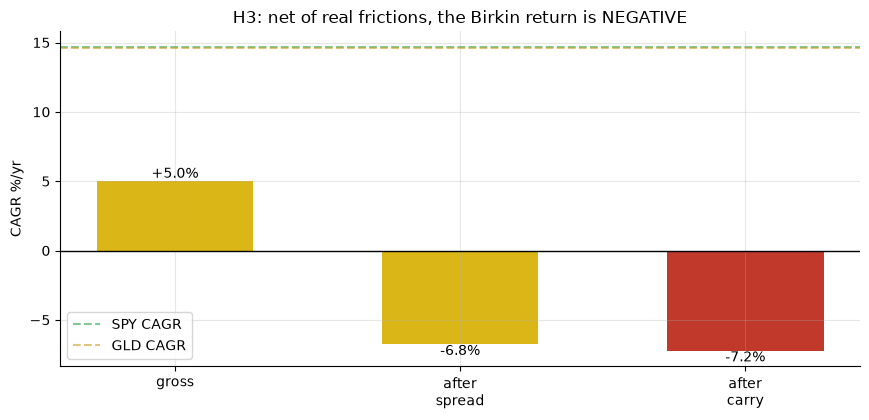

gross +5.01%  - spread -11.21%/yr  - carry -0.50%/yr  =  NET -7.23%/yr


In [4]:
gross = si['cagr']
h = st.net_of_carry_cagr(gross, round_trip_spread=0.30, hold_years=3.0, insure_per_year=0.005)
steps = ['gross','after\nspread','after\ncarry']
running = [h['gross_cagr']*100,
           ((1+h['gross_cagr'])*(1+h['spread_drag_annual'])-1)*100,
           h['net_cagr']*100]
fig, ax = plt.subplots(figsize=(8.8,4.3))
cols=[AMBER, AMBER, (RED if running[-1]<0 else GREEN)]
ax.bar(steps, running, .55, color=cols)
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr_ye'], ls='--', c=GREEN, alpha=.6, label='SPY CAGR')
ax.axhline(R['gld_cagr_ye'], ls='--', c=GOLD, alpha=.6, label='GLD CAGR')
for i,v in enumerate(running): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('CAGR %/yr'); ax.set_title('H3: net of real frictions, the Birkin return is NEGATIVE'); ax.legend()
plt.tight_layout(); plt.show()
print(f"gross {h['gross_cagr']*100:+.2f}%  - spread {h['spread_drag_annual']*100:+.2f}%/yr  - carry {h['insure_per_year']*100:+.2f}%/yr  =  NET {h['net_cagr']*100:+.2f}%/yr")

> 💡 In plain words: the gross **5.0%** — already a loser to both SPY and gold — goes **negative (-7.2%/yr)** once you pay the ~30% consignment spread and carry to own the physical bag. And this is *charitable*: a quoted resale level is a dealer ask, so a real seller's realised return is lower still. H₃ rejected. **MIRAGE** is the only honest stamp.

### 4d · Positive control — the engine recovers a planted compounder

A deterministic steady-compounder (planted +12% CAGR, σ=3%/mo, seed 711) — the "it only goes up" path the pitch imagines. The harness must recover the up-sign and a finite Sharpe, proving the nulls above are real, not a broken pipeline.

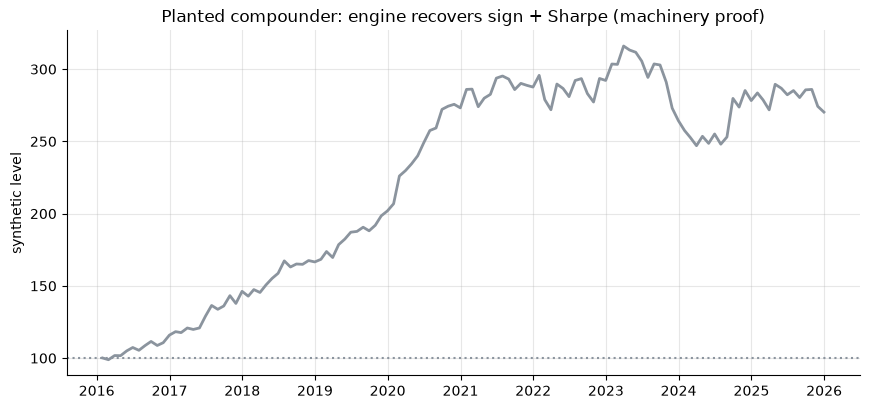

peak 316 -> end 270  recovered CAGR +10.54%  Sharpe 1.00  maxDD -21.8%  sign_ok=1


In [5]:
syn = data.synthetic_compounder()
s = st.summarize(syn); cr = st.control_recovers(syn, planted_sign=1)
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.plot(syn.index, syn.values, c=GREY, lw=2)
ax.axhline(100, ls=':', c=GREY)
ax.set_ylabel('synthetic level'); ax.set_title('Planted compounder: engine recovers sign + Sharpe (machinery proof)')
plt.tight_layout(); plt.show()
print(f"peak {syn.max():.0f} -> end {syn.iloc[-1]:.0f}  recovered CAGR {s['cagr']*100:+.2f}%  Sharpe {s['sharpe']:.2f}  maxDD {s['mdd']*100:.1f}%  sign_ok={cr['sign_ok']}")

> 💡 In plain words: the engine banks the planted signal (recovered CAGR ~+11%, Sharpe ~1.0, sign correct). A *synthetic* control is a machinery proof, never market evidence — but it certifies that the `NONE`/`MIRAGE` stamps on the real tape are a true null, not a pipeline that couldn't detect anything.

## 5 · The verdict

- **Signal `NONE`** — Birkin index CAGR 5.0% vs SPY 14.7% and GLD 14.6%; annual excess -10.7%/yr (*t* = -1.95) vs SPY and -10.9%/yr (*t* = -1.52) vs gold. The single closest leg, RMS.PA equity, is NW *t* = +1.93 < 2 — no robust *t* ≥ 2 anywhere in the bag's favour, and it isn't the bag.
- **Tradability `MIRAGE`** — gross +5.0% → net **-7.2%/yr** after a 30% consignment spread + carry; the buyable proxies are single-stock luxury beta (KER.PA maxDD -74%). Illiquid, wide-spread, no scalable book.
- **Beats stocks & gold? `BUSTED`** — the bag loses the return race to **both** named benchmarks and goes negative net-of-cost. The famous 14%/yr is a cherry-picked 1980–2015 window with survivorship baked in — a marketing statistic, not a tradable asset class.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$15,000 invested end-2015 (≈ one entry Birkin): S&P index fund vs gold ETF vs a bag flipper paying the real frictions (net CAGR from 4c). Capacity is the other wall: each bag is a bespoke, illiquid, ~30%-spread consignment — there is no scalable book.

C:\Users\loutr\AppData\Local\Temp\ipykernel_11440\488309385.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels, rotation=12, ha='right')


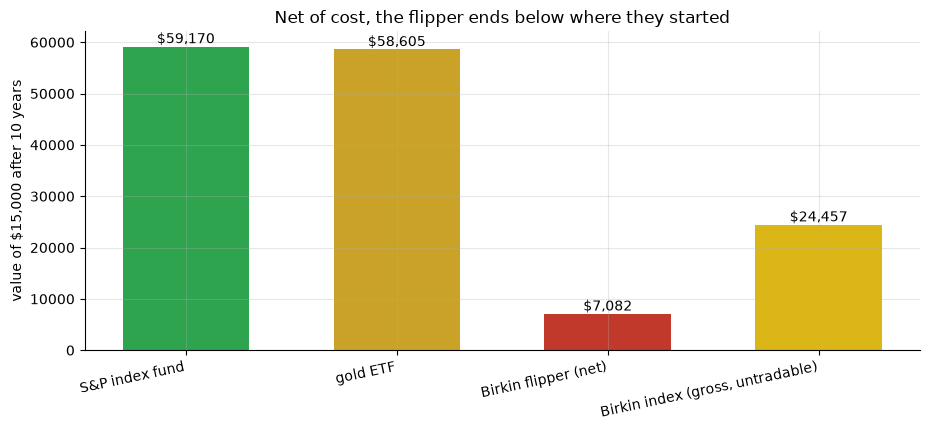

S&P index fund                     $    59,170  (+14.7%/yr)
gold ETF                           $    58,605  (+14.6%/yr)
Birkin flipper (net)               $     7,082  (-7.2%/yr)
Birkin index (gross, untradable)   $    24,457  (+5.0%/yr)


In [6]:
start=15_000.0; yrs_h=10
paths={'S&P index fund':R['spy_cagr_ye']/100, 'gold ETF':R['gld_cagr_ye']/100,
       'Birkin flipper (net)':R['carry_net']/100,
       'Birkin index (gross, untradable)':R['idx_cagr']/100}
fig, ax = plt.subplots(figsize=(9.4,4.4))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, GOLD, RED, AMBER]
ax.bar(labels, ends, .6, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_xticklabels(labels, rotation=12, ha='right')
ax.set_ylabel('value of $15,000 after 10 years'); ax.set_title('Net of cost, the flipper ends below where they started')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:34s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: even the *gross, untradable* index trails both the S&P and gold; the *tradable* version (net of the consignment spread + carry) ends **below the starting stake**. And capacity is fatal — a Birkin flip is a one-off illiquid trade with a ~30% round-trip, the antithesis of a scalable strategy. There is no sizing or venue that turns this into an edge.

## 7 · Going further

- **Swap in a live handbag index.** Replace the hardcoded series with the Knight Frank Luxury Investment Index handbag component or an Art Market Research handbag index and re-run; the *t*-stats sharpen but the sign won't flip.
- **Per-reference dispersion.** The aggregate hides survivorship: test individual references (Himalaya, diamond Kelly, standard Togo 30) — the record-setters are a thin selected tail, the bias points *for* the claim, so correct for it.
- **The collectibles prior.** Dimson–Spaenjers and the emotional-assets literature: collectibles under-perform equities net of carry across the board (see [Study 358 — Watch-Index](../../358-watch-index/) and [docs/references.md](../docs/references.md)). Handbags are not the exception.

*The reproducible core is offline and deterministic; the resale index is a **cited, approximate proxy** and the equity/gold tickers are **labelled proxies** for the trade. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*